# Part 3: Backbone Models and Fine-Tuning (Local GPU)
## Face Age Estimation — Autoencoders, Transfer Learning & Pretrained Backbones

---

### What this notebook covers
| Step | Task | Data |
|------|------|------|
| 1 | Split non-test data → Block 1 & Block 2 | train.csv + val.csv |
| 2 | Train a **Convolutional Autoencoder** to reconstruct face images | Block 1 |
| 3 | **Transfer Learning** — freeze AE encoder, train classification head | Block 2 |
| 4 | **ResNet-18 backbone** (ImageNet pretrained) fine-tuned for age classification | Block 2 |
| 5 | Compare all models against Part 1 baseline | Test set |

### Before running
Make sure you have completed Part 1 notebook first — this notebook needs:
- `data/train.csv`, `data/val.csv`, `data/test.csv`
- `saved_models/best_regression.pth`, `saved_models/best_classification.pth`
- All model class definitions (FlexCNN, ResCNN, etc.) — they are redefined here for independence

- Block split: instant
- Autoencoder training (30 epochs)
- Transfer learning (30 epochs)
- ResNet-18 fine-tuning (30 epochs)


## Cell 1 — Imports, Device Setup & Constants

Sets up the GPU device, seeds for reproducibility, and all constants.
All outputs (models, plots) are saved to the same folder as this notebook.

In [ ]:
import os, sys, random, shutil, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, mean_absolute_error)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms

#  Reproducibility 
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# Device 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
if DEVICE.type == 'cuda':
    props = torch.cuda.get_device_properties(0)
    vram  = props.total_memory / 1e9
    print(f'GPU     : {props.name}')
    print(f'VRAM    : {vram:.1f} GB')
    if vram < 5:
        print('NOTE: < 5GB VRAM detected — using batch_size=32 automatically')
else:
    print('WARNING: No GPU found — training will be slow')

#  num_workers: must be 0 on Windows 
NUM_WORKERS = 0 if platform.system() == 'Windows' else 4
print(f'num_workers : {NUM_WORKERS}')

#  Constants — must match Part 1 exactly 
IMG_SIZE    = 64
AE_SIZE     = 64      # autoencoder input size (same as Part 1)
BB_SIZE     = 224     # ResNet-18 requires 224x224
NUM_CLASSES = 6       # child, teen, youth, mid, mature, older
PART1_ACC   = 0.7185  # best classification accuracy from Part 1 — update if different
CAT_NAMES   = ['child', 'teen', 'youth', 'mid', 'mature', 'older']
CATEGORIES  = [('child',0,12),('teen',13,19),('youth',20,30),
               ('mid',31,45),('mature',46,60),('older',61,120)]

#  Batch size: auto-reduce for < 5GB VRAM 
VRAM_GB    = torch.cuda.get_device_properties(0).total_memory / 1e9 if DEVICE.type=='cuda' else 0
BATCH_SIZE = 32 if VRAM_GB < 5 else 64
print(f'Batch size  : {BATCH_SIZE}')

os.makedirs('data',         exist_ok=True)
os.makedirs('saved_models', exist_ok=True)
os.makedirs('outputs',      exist_ok=True)
print('\nAll imports successful ')


C:\Users\chand\AppData\Roaming\Python\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Device  : cuda
GPU     : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM    : 4.3 GB
NOTE: < 5GB VRAM detected — using batch_size=32 automatically
num_workers : 0
Batch size  : 32

All imports successful ✅


## Cell 2 — Verify Part 1 Files Exist

Checks that all required files from Part 1 are present before proceeding.  
If any are missing, re-run the Part 1 notebook first.


In [ ]:
required = [
    'data/train.csv',
    'data/val.csv',
    'data/test.csv',
    'saved_models/best_regression.pth',
    'saved_models/best_classification.pth',
]
all_ok = True
for f in required:
    exists = os.path.exists(f)
    status = 'ok' if exists else '  MISSING'
    print(f'  {status}  {f}')
    if not exists:
        all_ok = False

if not all_ok:
    raise FileNotFoundError(
        'Some Part 1 files are missing. '
        'Please run the Part 1 notebook first and make sure this '
        'notebook is in the same folder.'
    )
print('\nAll Part 1 files found ')


  ✅  data/train.csv
  ✅  data/val.csv
  ✅  data/test.csv
  ✅  saved_models/best_regression.pth
  ✅  saved_models/best_classification.pth

All Part 1 files found ✅


## Cell 3 - Shared Dataset Class & Transforms

Redefines `FaceAgeDataset` from Part 1 so this notebook is self-contained.  
Three transform sets are defined:

| Transform | Used for | Size | Normalisation |
|-----------|----------|------|---------------|
| `ae_train_tf` / `ae_eval_tf` | Autoencoder + Transfer Learning | 64×64 | `[-1, 1]` to match `Tanh` decoder |
| `bb_train_tf` / `bb_eval_tf` | ResNet-18 backbone | 224×224 | ImageNet mean/std |

**Why different normalisation?**  
The AE decoder uses `Tanh` output (range `[-1,1]`), so inputs must match.  
ResNet-18 was pretrained with ImageNet statistics — using different stats would
misalign its pretrained filters and hurt accuracy.


In [ ]:
def age_to_category(age):
    for idx, (name, lo, hi) in enumerate(CATEGORIES):
        if lo <= age <= hi:
            return idx, name
    return len(CATEGORIES) - 1, CATEGORIES[-1][0]


class FaceAgeDataset(Dataset):
    """
    Loads face images from a CSV file.
    Returns: (image_tensor, age_float, category_int)
    """
    def __init__(self, csv_path, transform=None, channels=3):
        self.df        = pd.read_csv(csv_path)
        self.transform = transform
        self.channels  = channels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = Image.open(row['path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        age = torch.tensor(row['age'],          dtype=torch.float32)
        cat = torch.tensor(row['category_idx'], dtype=torch.long)
        return img, age, cat


#  Autoencoder / Transfer Learning transforms 
# Normalise to [-1, 1] — matches Tanh decoder output range
ae_train_tf = transforms.Compose([
    transforms.Resize((AE_SIZE, AE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])
ae_eval_tf = transforms.Compose([
    transforms.Resize((AE_SIZE, AE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

#  ResNet-18 backbone transforms 
# Must use ImageNet mean/std - ResNet was pretrained with these exact values
bb_train_tf = transforms.Compose([
    transforms.Resize((BB_SIZE, BB_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
bb_eval_tf = transforms.Compose([
    transforms.Resize((BB_SIZE, BB_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def make_loader(csv_path, transform, batch_size=BATCH_SIZE, shuffle=False):
    ds = FaceAgeDataset(csv_path, transform=transform)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=NUM_WORKERS,
                      pin_memory=(DEVICE.type == 'cuda'))


#  Quick sanity check 
ds_check = FaceAgeDataset('data/train.csv', transform=ae_eval_tf)
img, age, cat = ds_check[0]
print(f'Dataset loaded  : {len(ds_check)} samples')
print(f'Image shape     : {img.shape}  (C×H×W)')
print(f'Image range     : [{img.min():.2f}, {img.max():.2f}]  (should be -1 to 1)')
print(f'Sample age      : {age.item():.0f}y  → category {cat.item()} ({CAT_NAMES[cat.item()]})')


Dataset loaded  : 7335 samples
Image shape     : torch.Size([3, 64, 64])  (C×H×W)
Image range     : [-0.95, 0.70]  (should be -1 to 1)
Sample age      : 39y  → category 3 (mid)


## Cell 4 — Split Non-Test Data into Block 1 and Block 2

Combines `train.csv` and `val.csv` (everything except the held-out test set)
and randomly splits 50/50 into two independent subsets.

| Block | Purpose | Size |
|-------|---------|------|
| **Block 1** | Train the Autoencoder (unsupervised) | 50% of non-test |
| **Block 2** | Train Transfer Learning & ResNet-18 classifiers | 50% of non-test |

**Why keep them separate?**  
The autoencoder sees Block 1 images during unsupervised pretraining.
If Block 2 overlapped, the encoder would have already memorised those images,
giving the transfer learning classifier an unfair advantage and inflating results.

The fixed `random_state=SEED` ensures the same split every run.


Train  : 7,335
Val    : 1,466
Total  : 8,801

✅ Block 1 (Autoencoder) : 4,400 samples → data/block1.csv
✅ Block 2 (Classifiers) : 4,401 samples → data/block2.csv


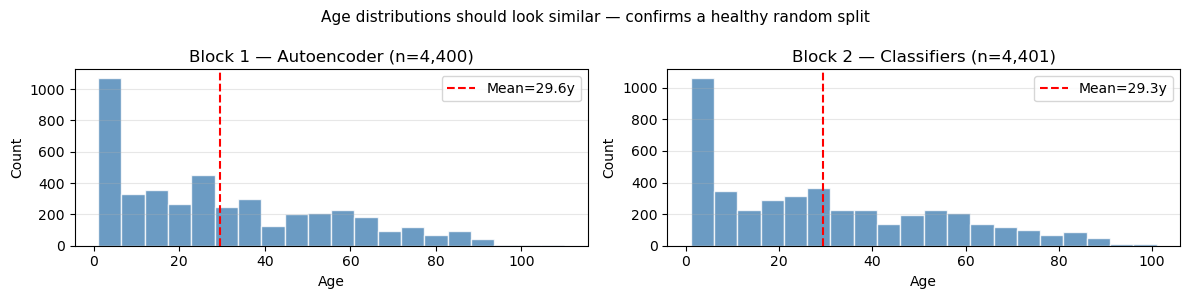

✅ outputs/block_split.png


In [ ]:
#  Load all non-test data 
train_df = pd.read_csv('data/train.csv')
val_df   = pd.read_csv('data/val.csv')
non_test = pd.concat([train_df, val_df], ignore_index=True)

print(f'Train  : {len(train_df):,}')
print(f'Val    : {len(val_df):,}')
print(f'Total  : {len(non_test):,}')

#  Random 50/50 split 
non_test  = non_test.sample(frac=1, random_state=SEED).reset_index(drop=True)
mid       = len(non_test) // 2
block1_df = non_test.iloc[:mid].reset_index(drop=True)
block2_df = non_test.iloc[mid:].reset_index(drop=True)

block1_df.to_csv('data/block1.csv', index=False)
block2_df.to_csv('data/block2.csv', index=False)

print(f'\n Block 1 (Autoencoder) : {len(block1_df):,} samples → data/block1.csv')
print(f' Block 2 (Classifiers) : {len(block2_df):,} samples → data/block2.csv')

#  Plot: verify age distributions are similar (healthy split) 
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, df, title in [(axes[0], block1_df, 'Block 1 — Autoencoder'),
                       (axes[1], block2_df, 'Block 2 — Classifiers')]:
    ax.hist(df['age'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df['age'].mean(), color='red', linestyle='--',
               label=f'Mean={df["age"].mean():.1f}y')
    ax.set(title=f'{title} (n={len(df):,})', xlabel='Age', ylabel='Count')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.suptitle('Age distributions should look similar — confirms a healthy random split',
             fontsize=11)
plt.tight_layout()
plt.savefig('outputs/block_split.png', dpi=150)
plt.show()
print(' outputs/block_split.png')


## Cell 5 - Convolutional Autoencoder Architecture

The autoencoder mirrors the **best FlexCNN encoder from Part 1** (5 conv blocks,
channels `[32, 64, 128, 256, 256]`) and adds a symmetric decoder.



**Loss function discussion:**

| Loss | Formula | Behaviour |
|------|---------|-----------|
| **MSE** *(primary)* | mean((x-x̂)²) | Penalises large errors heavily; can produce slightly blurry results |
| **MAE** *(tracked)* | mean(\|x-x̂\|) | More robust to outlier pixels; more interpretable (per-pixel error) |
| **SSIM** *(future)* | structural similarity | Perceptual quality; preserves edges & textures better than pixel losses |

MSE is used for gradient updates (standard AE baseline). MAE is logged each
epoch as a more human-readable metric. Lower MSE = better reconstruction.


In [ ]:
class ConvAutoencoder(nn.Module):
    """
    Convolutional Autoencoder that mirrors the Part 1 FlexCNN depth-5 encoder.

    Encoder : 5 × (Conv3×3 → BN → ReLU → MaxPool2)  [64→2 spatial]
    Bottleneck: Linear(256×2×2 → latent_dim)
    Decoder : Linear(latent_dim → 256×2×2) + 5 × ConvTranspose2d [2→64 spatial]
    """
    def __init__(self, latent_dim: int = 512, in_channels: int = 3):
        super().__init__()
        self.latent_dim = latent_dim

        #  Encoder 
        self.encoder = nn.Sequential(
            # Block 0: 64×64 → 32×32,   3 →  32 ch
            nn.Conv2d(in_channels, 32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            # Block 1: 32×32 → 16×16,  32 →  64 ch
            nn.Conv2d(32,  64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            # Block 2: 16×16 →  8×8,   64 → 128 ch
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            # Block 3:  8×8  →  4×4,  128 → 256 ch
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            # Block 4:  4×4  →  2×2,  256 → 256 ch
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        # After encoder on 64×64 input: spatial = 2×2, channels = 256 → flat 1024
        self._flat = 256 * 2 * 2
        self.fc_enc    = nn.Linear(self._flat, latent_dim)

        #  Decoder 
        self.fc_dec    = nn.Linear(latent_dim, self._flat)
        self.unflatten = nn.Unflatten(1, (256, 2, 2))
        self.decoder   = nn.Sequential(
            #  2×2  →  4×4,  256 → 256 ch
            nn.ConvTranspose2d(256, 256, 2, stride=2), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            #  4×4  →  8×8,  256 → 128 ch
            nn.ConvTranspose2d(256, 128, 2, stride=2), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            #  8×8  → 16×16, 128 →  64 ch
            nn.ConvTranspose2d(128, 64,  2, stride=2), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            # 16×16 → 32×32,  64 →  32 ch
            nn.ConvTranspose2d(64,  32,  2, stride=2), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            # 32×32 → 64×64,  32 →   3 ch
            nn.ConvTranspose2d(32,   3,  2, stride=2),
            nn.Tanh()   # output in [-1, 1] matching input normalisation
        )

    def forward(self, x):
        """Returns (reconstruction, latent_vector)."""
        z    = self.fc_enc(self.encoder(x).flatten(1))
        xhat = self.decoder(self.unflatten(self.fc_dec(z)))
        return xhat, z

    def encode(self, x):
        """Extract latent vector only — used during transfer learning."""
        return self.fc_enc(self.encoder(x).flatten(1))


#  Sanity check 
ae_tmp  = ConvAutoencoder(latent_dim=512)
dummy   = torch.randn(2, 3, AE_SIZE, AE_SIZE)
recon, z = ae_tmp(dummy)
enc_p   = sum(p.numel() for p in ae_tmp.encoder.parameters())
dec_p   = sum(p.numel() for p in ae_tmp.decoder.parameters())
tot_p   = sum(p.numel() for p in ae_tmp.parameters())
print(f'ConvAutoencoder')
print(f'  Encoder params : {enc_p:,}')
print(f'  Decoder params : {dec_p:,}')
print(f'  Total params   : {tot_p:,}')
print(f'  Input  shape   : {dummy.shape}')
print(f'  Latent shape   : {z.shape}     (bottleneck)')
print(f'  Output shape   : {recon.shape} (must match input) ')
del ae_tmp, dummy, recon, z


ConvAutoencoder
  Encoder params : 979,968
  Decoder params : 436,003
  Total params   : 2,466,083
  Input  shape   : torch.Size([2, 3, 64, 64])
  Latent shape   : torch.Size([2, 512])     (bottleneck)
  Output shape   : torch.Size([2, 3, 64, 64]) (must match input) ✅


## Cell 6 - Train Autoencoder on Block 1

**Training strategy:**
- **Adam** optimiser with `weight_decay=1e-5` for light regularisation
- **Cosine annealing** LR schedule: smoothly decays from `1e-3` to near-zero
  avoiding the abrupt drops of step schedulers → better final minima
- **Gradient clipping** at `max_norm=1.0` prevents exploding gradients in decoder
- **Best checkpoint** saved whenever val MSE improves, not just at last epoch
- 80/20 split within Block 1 for AE training/validation



In [6]:
def train_autoencoder(epochs=30, lr=1e-3, latent_dim=512):
    #  DataLoaders — 80/20 split within Block 1 
    ds_tr  = FaceAgeDataset('data/block1.csv', transform=ae_train_tf)
    ds_va  = FaceAgeDataset('data/block1.csv', transform=ae_eval_tf)
    n      = len(ds_tr)
    idx    = list(range(n)); random.shuffle(idx)
    split  = int(0.8 * n)

    tr_loader = DataLoader(Subset(ds_tr, idx[:split]), batch_size=BATCH_SIZE,
                           shuffle=True,  num_workers=NUM_WORKERS,
                           pin_memory=(DEVICE.type=='cuda'))
    va_loader = DataLoader(Subset(ds_va, idx[split:]), batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=NUM_WORKERS,
                           pin_memory=(DEVICE.type=='cuda'))
    print(f'AE Train : {len(idx[:split]):,} | Val : {len(idx[split:]):,}')

    #  Model, optimiser, scheduler 
    model  = ConvAutoencoder(latent_dim=latent_dim).to(DEVICE)
    opt    = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-5)
    mse_fn = nn.MSELoss()
    mae_fn = nn.L1Loss()

    history    = {'train_mse': [], 'val_mse': [], 'val_mae': []}
    best_val   = float('inf')
    best_state = None

    print(f'\nTraining ConvAutoencoder — {epochs} epochs')
    print(f'{"Epoch":>6} | {"Train MSE":>10} | {"Val MSE":>10} | {"Val MAE":>10} | {"LR":>10}')
    print('-' * 58)

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        run_mse = 0.0
        for imgs, _, _ in tr_loader:
            imgs = imgs.to(DEVICE)
            opt.zero_grad()
            recon, _ = model(imgs)
            loss = mse_fn(recon, imgs)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            run_mse += loss.item() * imgs.size(0)
        train_mse = run_mse / len(tr_loader.dataset)

        # Validate
        model.eval()
        val_mse = val_mae = 0.0
        with torch.no_grad():
            for imgs, _, _ in va_loader:
                imgs     = imgs.to(DEVICE)
                recon, _ = model(imgs)
                val_mse += mse_fn(recon, imgs).item() * imgs.size(0)
                val_mae += mae_fn(recon, imgs).item() * imgs.size(0)
        val_mse /= len(va_loader.dataset)
        val_mae /= len(va_loader.dataset)

        history['train_mse'].append(train_mse)
        history['val_mse'].append(val_mse)
        history['val_mae'].append(val_mae)
        sched.step()

        if val_mse < best_val:
            best_val   = val_mse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            tag = ' ← best'
        else:
            tag = ''

        if epoch % 5 == 0 or epoch == 1:
            lr_now = opt.param_groups[0]['lr']
            print(f'{epoch:>6} | {train_mse:>10.4f} | {val_mse:>10.4f} | {val_mae:>10.4f} | {lr_now:>10.6f}{tag}')

    torch.save({
        'model_state_dict': best_state,
        'latent_dim'       : latent_dim,
        'img_size'         : AE_SIZE,
        'best_val_mse'     : best_val,
    }, 'saved_models/autoencoder.pth')

    model.load_state_dict(best_state)
    print(f'\n saved_models/autoencoder.pth  (best val MSE: {best_val:.4f})')
    return model, history


ae_model, ae_history = train_autoencoder(epochs=30, latent_dim=512)


AE Train : 3,520 | Val : 880

Training ConvAutoencoder — 30 epochs
 Epoch |  Train MSE |    Val MSE |    Val MAE |         LR
----------------------------------------------------------
     1 |     0.2112 |     0.1081 |     0.2512 |   0.000997 ← best
     5 |     0.0554 |     0.0546 |     0.1754 |   0.000934 ← best
    10 |     0.0389 |     0.0381 |     0.1434 |   0.000753
    15 |     0.0320 |     0.0310 |     0.1280 |   0.000505 ← best
    20 |     0.0278 |     0.0269 |     0.1171 |   0.000258 ← best
    25 |     0.0244 |     0.0252 |     0.1145 |   0.000076
    30 |     0.0233 |     0.0234 |     0.1080 |   0.000010 ← best

✅ saved_models/autoencoder.pth  (best val MSE: 0.0234)


## Cell 7 - Visualise Autoencoder Results

Produces two diagnostic plots:

1. **Loss curves** - Train MSE, Val MSE, Val MAE over epochs.
   Good training: both curves fall together. Val rising while train falls = overfitting.

2. **Reconstruction grid** - 8 original images vs their reconstructions.
   This is the most intuitive quality check. Early epochs produce blurry results;
   by epoch 25–30 faces should be clearly recognisable.

**What MSE values mean:**  
- `> 0.10` - poor reconstruction, major features missing  
- `0.04–0.10` - moderate, broad structure preserved  
- `< 0.04` - good, fine details visible  


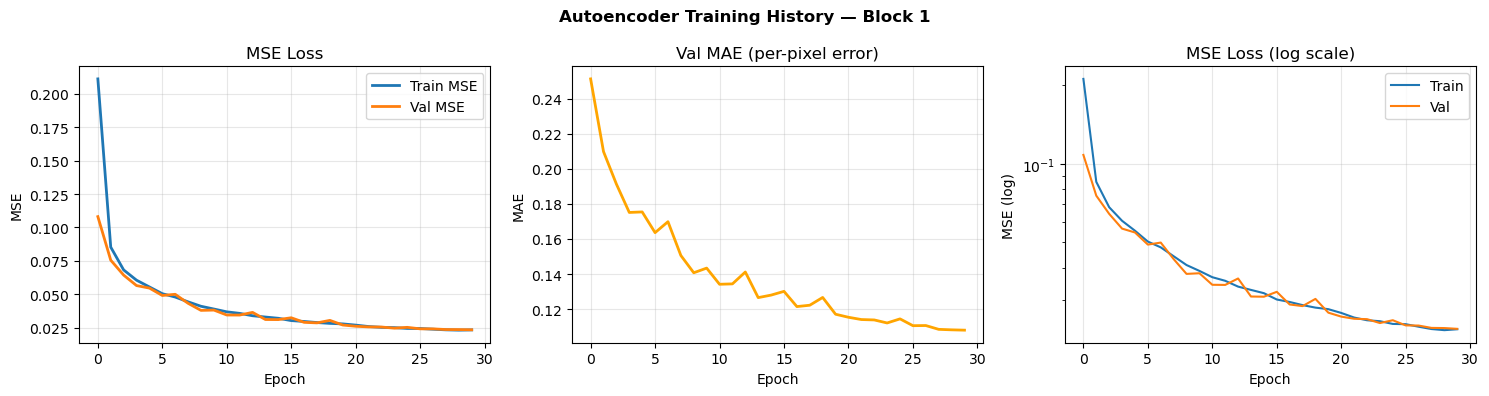

 outputs/ae_loss_curves.png


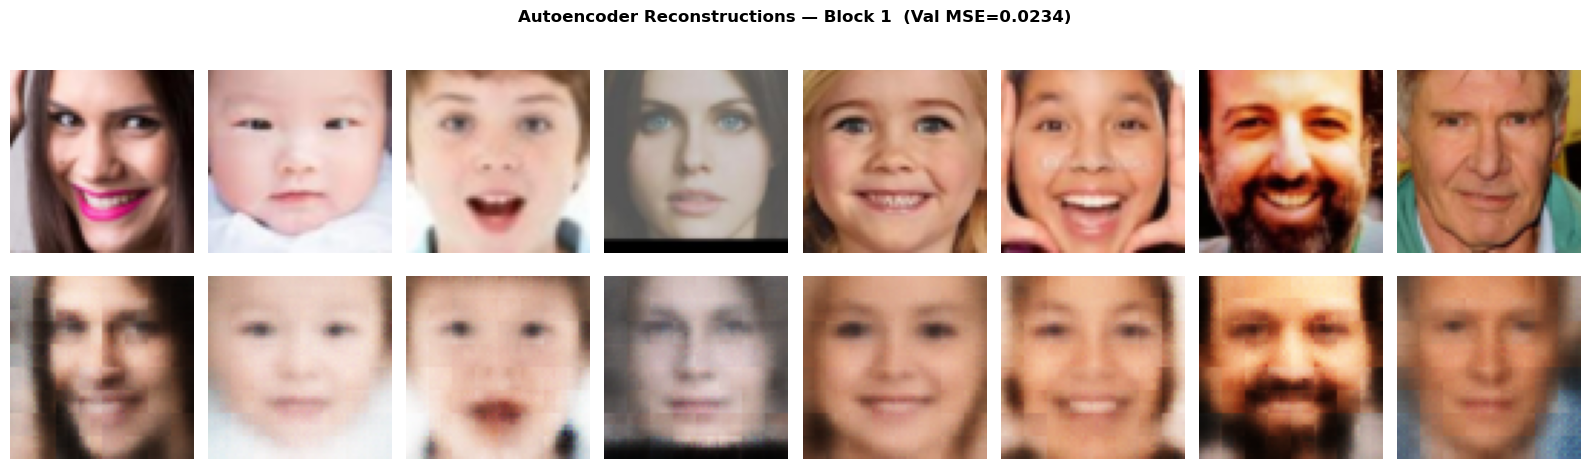

 outputs/ae_reconstructions.png

Latent vector stats (batch of 8):
  Mean : -0.0083
  Std  : 1.1648  (> 0.1 means not collapsed)


In [7]:
def denorm(t):
    """Convert [-1, 1] tensor back to [0, 1] for display."""
    return (t * 0.5 + 0.5).clamp(0, 1)


#  Loss curves 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(ae_history['train_mse'], label='Train MSE', linewidth=2)
axes[0].plot(ae_history['val_mse'],   label='Val MSE',   linewidth=2)
axes[0].set(title='MSE Loss', xlabel='Epoch', ylabel='MSE')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ae_history['val_mae'], color='orange', linewidth=2)
axes[1].set(title='Val MAE (per-pixel error)', xlabel='Epoch', ylabel='MAE')
axes[1].grid(True, alpha=0.3)

axes[2].plot(ae_history['train_mse'], label='Train')
axes[2].plot(ae_history['val_mse'],   label='Val')
axes[2].set_yscale('log')
axes[2].set(title='MSE Loss (log scale)', xlabel='Epoch', ylabel='MSE (log)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Autoencoder Training History — Block 1', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/ae_loss_curves.png', dpi=150)
plt.show()
print(' outputs/ae_loss_curves.png')

#  Reconstruction grid 
N_SHOW  = 8
ds_vis  = FaceAgeDataset('data/block1.csv', transform=ae_eval_tf)
vis_idx = [int(i) for i in np.linspace(0, len(ds_vis)-1, N_SHOW)]
vis_imgs = torch.stack([ds_vis[i][0] for i in vis_idx]).to(DEVICE)

ae_model.eval()
with torch.no_grad():
    recons, latents = ae_model(vis_imgs)

fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 2, 5))
for i in range(N_SHOW):
    axes[0, i].imshow(denorm(vis_imgs[i]).cpu().permute(1, 2, 0))
    axes[0, i].axis('off')
    axes[1, i].imshow(denorm(recons[i]).cpu().permute(1, 2, 0))
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original',      fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Reconstructed', fontsize=10, fontweight='bold')
plt.suptitle(f'Autoencoder Reconstructions — Block 1  (Val MSE={min(ae_history["val_mse"]):.4f})',
             fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/ae_reconstructions.png', dpi=150)
plt.show()
print(' outputs/ae_reconstructions.png')

print(f'\nLatent vector stats (batch of {N_SHOW}):')
print(f'  Mean : {latents.mean().item():.4f}')
print(f'  Std  : {latents.std().item():.4f}  (> 0.1 means not collapsed)')


## Cell 8 - Transfer Learning Classifier (Block 2)

Uses the **frozen AE encoder** as a fixed feature extractor, attaches a
classification head, and trains on Block 2.

**Two-phase training strategy:**

```
Phase 1 (15 epochs) - Encoder FROZEN, LR = 1e-3
  Only the classification head trains.
  Fast convergence; protects the pretrained encoder features.

Phase 2 (15 epochs) - Encoder UNFROZEN, LR = 1e-4
  Full end-to-end fine-tuning with a very small LR.
  Small targeted adjustments without catastrophic forgetting.
  Cosine annealing schedule.
```

**Transfer learning hypothesis:**  
The AE was forced to learn compact, information-rich face representations
without any labels. If those representations capture age-relevant features
(wrinkles, bone structure, skin texture), the classifier should generalise
better than training from scratch on the limited Block 2 data.



In [ ]:
class AEClassifier(nn.Module):
    """
    Age classifier built on the pretrained AE encoder.

    [Pretrained] AE Encoder → latent_dim (512)
    [Trainable]  Linear(512→256) → ReLU → Dropout(0.4)
                 Linear(256→128) → ReLU → Dropout(0.3)
                 Linear(128→NUM_CLASSES)
    """
    def __init__(self, ae_model, num_classes=NUM_CLASSES,
                 latent_dim=512, freeze_encoder=True):
        super().__init__()
        # Borrow encoder weights from trained AE
        self.encoder = ae_model.encoder
        self.fc_enc  = ae_model.fc_enc

        if freeze_encoder:
            for p in list(self.encoder.parameters()) + list(self.fc_enc.parameters()):
                p.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(256, 128),        nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        z = self.fc_enc(self.encoder(x).flatten(1))
        return self.classifier(z)

    def unfreeze_encoder(self):
        for p in list(self.encoder.parameters()) + list(self.fc_enc.parameters()):
            p.requires_grad = True


def train_transfer(ae_model, epochs_frozen=15, epochs_unfrozen=15,
                   lr_frozen=1e-3, lr_unfrozen=1e-4):
    #  DataLoaders — Block 2, 80/20 split 
    ds_tr  = FaceAgeDataset('data/block2.csv', transform=ae_train_tf)
    ds_va  = FaceAgeDataset('data/block2.csv', transform=ae_eval_tf)
    n      = len(ds_tr); idx = list(range(n)); random.shuffle(idx)
    split  = int(0.8 * n)
    tr_loader = DataLoader(Subset(ds_tr, idx[:split]), batch_size=BATCH_SIZE,
                           shuffle=True,  num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
    va_loader = DataLoader(Subset(ds_va, idx[split:]), batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
    print(f'TL Train : {len(idx[:split]):,} | Val : {len(idx[split:]):,}')

    model    = AEClassifier(ae_model, freeze_encoder=True).to(DEVICE)
    ce       = nn.CrossEntropyLoss()
    history  = {'val_acc': [], 'phase': []}
    best_acc, best_state = 0.0, None

    def one_epoch(opt):
        model.train()
        for imgs, _, labels in tr_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad()
            ce(model(imgs), labels).backward()
            opt.step()
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for imgs, _, labels in va_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                correct += (model(imgs).argmax(1) == labels).sum().item()
                total   += labels.size(0)
        return correct / total

    # Phase 1 — head only
    print('\nPhase 1 — Head only (AE encoder frozen)')
    opt1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr_frozen)
    for ep in range(1, epochs_frozen + 1):
        acc = one_epoch(opt1)
        history['val_acc'].append(acc); history['phase'].append(1)
        if acc > best_acc:
            best_acc = acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if ep % 5 == 0: print(f'  Epoch {ep:02d} | Val Acc {acc:.4f}')

    # Phase 2 — full fine-tune
    print('\nPhase 2 — Full fine-tune (encoder unfrozen, low LR)')
    model.unfreeze_encoder()
    opt2  = optim.Adam(model.parameters(), lr=lr_unfrozen, weight_decay=1e-5)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=epochs_unfrozen, eta_min=1e-6)
    for ep in range(1, epochs_unfrozen + 1):
        acc = one_epoch(opt2); sched.step()
        history['val_acc'].append(acc); history['phase'].append(2)
        if acc > best_acc:
            best_acc = acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if ep % 5 == 0: print(f'  Epoch {ep:02d} | Val Acc {acc:.4f}')

    torch.save({'model_state_dict': best_state, 'num_classes': NUM_CLASSES},
               'saved_models/transfer_classifier.pth')
    model.load_state_dict(best_state)
    print(f'\n saved_models/transfer_classifier.pth  (best val acc: {best_acc:.4f})')
    return model, history, best_acc


tl_model, tl_history, tl_best_acc = train_transfer(ae_model)


TL Train : 3,520 | Val : 881

Phase 1 — Head only (AE encoder frozen)
  Epoch 05 | Val Acc 0.5834
  Epoch 10 | Val Acc 0.5743


## Cell 9 - ResNet-18 Backbone (ImageNet Pretrained)

Fine-tunes **ResNet-18** pretrained on ImageNet for age category classification.

**Why ResNet-18?**
- Pretrained on 1.2 million ImageNet images → already knows edges, textures, shapes
- Residual connections prevent vanishing gradients during fine-tuning
- Strong, well-understood baseline for transfer learning comparisons

**Key difference from AE Transfer Learning:**  
The AE encoder was trained *unsupervised on our face dataset only*.  
ResNet-18 was trained *supervised on 1.2M diverse ImageNet images*.  
This gives ResNet far richer low-level feature detectors - which is why
we expect it to outperform the AE-based approach.

**Architecture change:**  
ResNet's final FC layer (`512 → 1000 classes`) is replaced with our
custom head (`512 → 256 → 128 → 6 age categories`).



In [ ]:
class BackboneClassifier(nn.Module):
    """
    ResNet-18 (ImageNet pretrained) with custom age-classification head.

    [Pretrained] ResNet-18 backbone → 512-dim feature vector
    [Trainable]  Linear(512→256) → ReLU → Dropout(0.4)
                 Linear(256→128) → ReLU → Dropout(0.3)
                 Linear(128→NUM_CLASSES)
    """
    def __init__(self, num_classes=NUM_CLASSES, freeze_backbone=True):
        super().__init__()
        weights       = models.ResNet18_Weights.IMAGENET1K_V1
        base          = models.resnet18(weights=weights)
        in_feats      = base.fc.in_features   # 512

        # Drop the original ImageNet FC layer, keep the feature extractor
        self.backbone = nn.Sequential(*list(base.children())[:-1])  # → (B,512,1,1)

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_feats, 256), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(256, 128),      nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))

    def unfreeze(self):
        for p in self.backbone.parameters():
            p.requires_grad = True


def train_backbone(epochs_frozen=10, epochs_unfrozen=20,
                   lr_frozen=1e-3, lr_unfrozen=5e-5):
    # Use smaller batch for 224×224 images on 4GB VRAM
    bb_batch = max(BATCH_SIZE // 2, 16)

    #  DataLoaders — Block 2 with ImageNet transforms 
    ds_tr  = FaceAgeDataset('data/block2.csv', transform=bb_train_tf)
    ds_va  = FaceAgeDataset('data/block2.csv', transform=bb_eval_tf)
    n      = len(ds_tr); idx = list(range(n)); random.shuffle(idx)
    split  = int(0.8 * n)
    tr_loader = DataLoader(Subset(ds_tr, idx[:split]), batch_size=bb_batch,
                           shuffle=True,  num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
    va_loader = DataLoader(Subset(ds_va, idx[split:]), batch_size=bb_batch,
                           shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
    print(f'BB Train : {len(idx[:split]):,} | Val : {len(idx[split:]):,} | Batch : {bb_batch}')

    model    = BackboneClassifier(freeze_backbone=True).to(DEVICE)
    ce       = nn.CrossEntropyLoss()
    history  = {'val_acc': [], 'phase': []}
    best_acc, best_state = 0.0, None

    def one_epoch(opt):
        model.train()
        for imgs, _, labels in tr_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad()
            ce(model(imgs), labels).backward()
            opt.step()
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for imgs, _, labels in va_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                correct += (model(imgs).argmax(1) == labels).sum().item()
                total   += labels.size(0)
        return correct / total

    # Phase 1 - head only
    print('\nPhase 1 - Head only (ResNet-18 backbone frozen)')
    opt1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr_frozen)
    for ep in range(1, epochs_frozen + 1):
        acc = one_epoch(opt1)
        history['val_acc'].append(acc); history['phase'].append(1)
        if acc > best_acc:
            best_acc = acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if ep % 5 == 0: print(f'  Epoch {ep:02d} | Val Acc {acc:.4f}')

    # Phase 2 - full fine-tune
    print('\nPhase 2 - Full ResNet-18 fine-tune (low LR)')
    model.unfreeze()
    opt2  = optim.Adam(model.parameters(), lr=lr_unfrozen, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=epochs_unfrozen, eta_min=1e-6)
    for ep in range(1, epochs_unfrozen + 1):
        acc = one_epoch(opt2); sched.step()
        history['val_acc'].append(acc); history['phase'].append(2)
        if acc > best_acc:
            best_acc = acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if ep % 5 == 0: print(f'  Epoch {ep:02d} | Val Acc {acc:.4f}')

    torch.save({'model_state_dict': best_state, 'num_classes': NUM_CLASSES},
               'saved_models/backbone_resnet18.pth')
    model.load_state_dict(best_state)
    print(f'\n saved_models/backbone_resnet18.pth  (best val acc: {best_acc:.4f})')
    return model, history, best_acc


bb_model, bb_history, bb_best_acc = train_backbone()


BB Train : 3,520 | Val : 881 | Batch : 16


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\chand/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [02:08<00:00, 364kB/s]   



Phase 1 — Head only (ResNet-18 backbone frozen)
  Epoch 05 | Val Acc 0.5709
  Epoch 10 | Val Acc 0.5925

Phase 2 — Full ResNet-18 fine-tune (low LR)
  Epoch 05 | Val Acc 0.7151
  Epoch 10 | Val Acc 0.7446
  Epoch 15 | Val Acc 0.7696
  Epoch 20 | Val Acc 0.7650

✅ saved_models/backbone_resnet18.pth  (best val acc: 0.7696)


## Cell 10 - Evaluate All Models on Held-Out Test Set

Runs all three Part 3 models on `data/test.csv` - the same test set
used to measure the Part 1 baseline (71.85%).

This gives a fair apples-to-apples comparison:
- Same test images, same evaluation metric (accuracy)
- Part 1 trained on train+val; Part 3 models trained on Block 1+2 (same data, different split)


In [ ]:
def evaluate_classifier(model, csv_path, transform, label='Model'):
    """Full test-set evaluation returning accuracy, predictions, and labels."""
    ds     = FaceAgeDataset(csv_path, transform=transform)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, _, labels in loader:
            preds = model(imgs.to(DEVICE)).argmax(1).cpu()
            all_preds.append(preds)
            all_labels.append(labels)
    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    acc    = accuracy_score(labels, preds)
    print(f'\n{label}')
    print(f'  Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
    print(classification_report(labels, preds,
          target_names=CAT_NAMES, zero_division=0))
    return acc, preds, labels


print(f'Test set: {len(pd.read_csv("data/test.csv")):,} samples')
print('=' * 55)

tl_acc, tl_preds, tl_labels = evaluate_classifier(
    tl_model, 'data/test.csv', ae_eval_tf,
    'Transfer Learning (AE Encoder + Block 2)')

bb_acc, bb_preds, bb_labels = evaluate_classifier(
    bb_model, 'data/test.csv', bb_eval_tf,
    'ResNet-18 Backbone (ImageNet + Block 2)')

print('\n' + '=' * 55)
print('COMPARISON SUMMARY')
print('=' * 55)
print(f'  Part 1 FlexCNN (baseline) : {PART1_ACC:.4f}')
print(f'  Transfer Learning (AE)    : {tl_acc:.4f}  ({tl_acc-PART1_ACC:+.4f} vs baseline)')
print(f'  ResNet-18 Backbone        : {bb_acc:.4f}  ({bb_acc-PART1_ACC:+.4f} vs baseline)')


Test set: 977 samples

Transfer Learning (AE Encoder + Block 2)
  Test Accuracy : 0.6428  (64.28%)
              precision    recall  f1-score   support

       child       0.91      0.94      0.92       319
        teen       0.53      0.31      0.39       106
       youth       0.53      0.64      0.58       166
         mid       0.40      0.41      0.40       124
      mature       0.44      0.41      0.42       140
       older       0.65      0.66      0.66       122

    accuracy                           0.64       977
   macro avg       0.58      0.56      0.56       977
weighted avg       0.64      0.64      0.64       977


ResNet-18 Backbone (ImageNet + Block 2)
  Test Accuracy : 0.7247  (72.47%)
              precision    recall  f1-score   support

       child       0.89      0.96      0.92       319
        teen       0.70      0.54      0.61       106
       youth       0.66      0.69      0.68       166
         mid       0.52      0.47      0.49       124
      matur

## Cell 11 - Final Comparison Plots

Produces a 2×3 figure covering:
1. **Accuracy bar chart** - all models vs Part 1 baseline
2. **Transfer Learning training curve** - shows frozen --unfrozen phase transition
3. **ResNet-18 training curve** - same two-phase pattern
4. **Autoencoder loss curve** - MSE convergence
5. **Transfer Learning confusion matrix**
6. **ResNet-18 confusion matrix**

The confusion matrices reveal *which age groups* are hardest to classify.
Adjacent categories (teen/youth, mid/mature) are typically confused most
because the visual difference between e.g. a 19-year-old and a 20-year-old
is minimal.


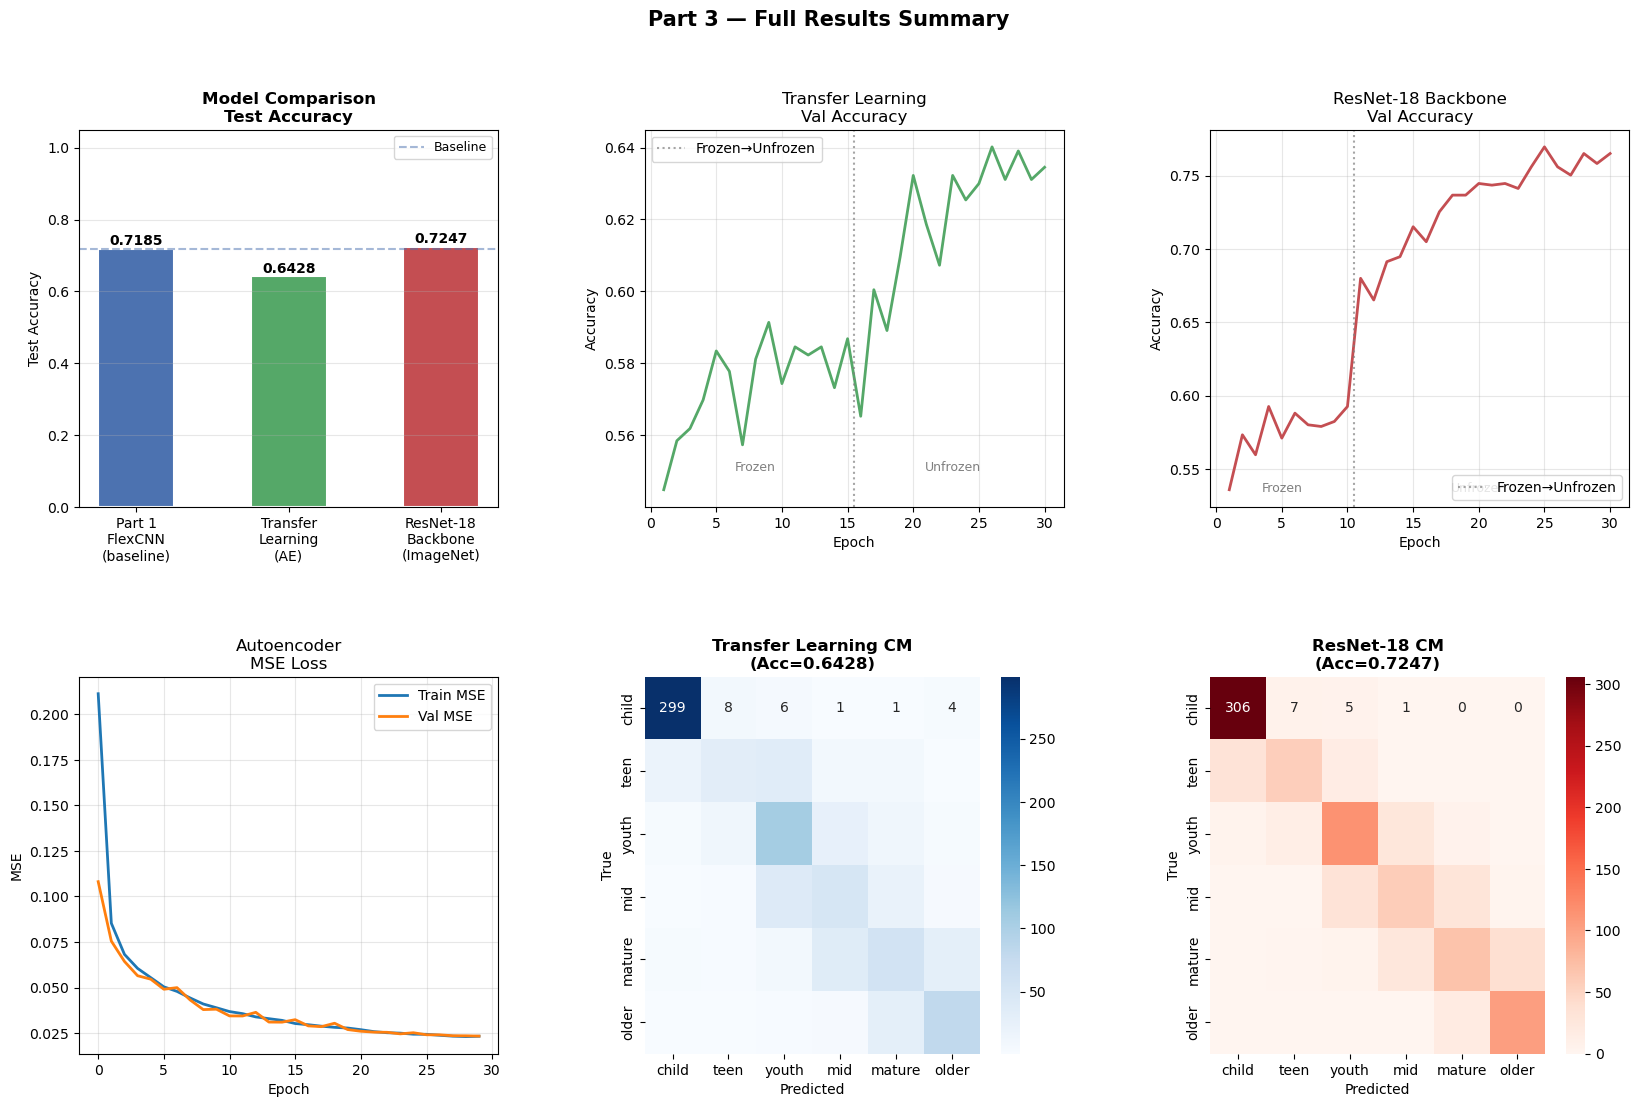

✅ outputs/part3_full_comparison.png


In [ ]:
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

#  1. Accuracy bar chart 
ax_bar = fig.add_subplot(gs[0, 0])
names  = ['Part 1\nFlexCNN\n(baseline)', 'Transfer\nLearning\n(AE)', 'ResNet-18\nBackbone\n(ImageNet)']
accs   = [PART1_ACC, tl_acc, bb_acc]
colours = ['#4C72B0', '#55A868', '#C44E52']
bars = ax_bar.bar(names, accs, color=colours, edgecolor='white', linewidth=1.5, width=0.5)
ax_bar.axhline(PART1_ACC, color='#4C72B0', linestyle='--', alpha=0.5, label='Baseline')
ax_bar.set_ylim(0, 1.05)
ax_bar.set_ylabel('Test Accuracy')
ax_bar.set_title('Model Comparison\nTest Accuracy', fontweight='bold')
ax_bar.legend(fontsize=9); ax_bar.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accs):
    ax_bar.text(bar.get_x() + bar.get_width()/2, acc + 0.01,
                f'{acc:.4f}', ha='center', fontsize=10, fontweight='bold')

#  2. Transfer Learning training curve 
ax_tl = fig.add_subplot(gs[0, 1])
ep_tl = list(range(1, len(tl_history['val_acc']) + 1))
ax_tl.plot(ep_tl, tl_history['val_acc'], color='#55A868', linewidth=2)
ax_tl.axvline(15.5, color='grey', linestyle=':', alpha=0.7, label='Frozen→Unfrozen')
ax_tl.set(title='Transfer Learning\nVal Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax_tl.legend(); ax_tl.grid(True, alpha=0.3)
ax_tl.text(8,  ax_tl.get_ylim()[0]+0.01, 'Frozen',   ha='center', color='grey', fontsize=9)
ax_tl.text(23, ax_tl.get_ylim()[0]+0.01, 'Unfrozen', ha='center', color='grey', fontsize=9)

#  3. ResNet-18 training curve 
ax_bb = fig.add_subplot(gs[0, 2])
ep_bb = list(range(1, len(bb_history['val_acc']) + 1))
ax_bb.plot(ep_bb, bb_history['val_acc'], color='#C44E52', linewidth=2)
ax_bb.axvline(10.5, color='grey', linestyle=':', alpha=0.7, label='Frozen→Unfrozen')
ax_bb.set(title='ResNet-18 Backbone\nVal Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax_bb.legend(); ax_bb.grid(True, alpha=0.3)
ax_bb.text(5,  ax_bb.get_ylim()[0]+0.01, 'Frozen',   ha='center', color='grey', fontsize=9)
ax_bb.text(20, ax_bb.get_ylim()[0]+0.01, 'Unfrozen', ha='center', color='grey', fontsize=9)

#  4. AE loss curve 
ax_ae = fig.add_subplot(gs[1, 0])
ax_ae.plot(ae_history['train_mse'], label='Train MSE', linewidth=2)
ax_ae.plot(ae_history['val_mse'],   label='Val MSE',   linewidth=2)
ax_ae.set(title='Autoencoder\nMSE Loss', xlabel='Epoch', ylabel='MSE')
ax_ae.legend(); ax_ae.grid(True, alpha=0.3)

#  5. Transfer Learning confusion matrix 
ax_cm1 = fig.add_subplot(gs[1, 1])
cm1 = confusion_matrix(tl_labels, tl_preds)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=ax_cm1,
            xticklabels=CAT_NAMES, yticklabels=CAT_NAMES)
ax_cm1.set_title(f'Transfer Learning CM\n(Acc={tl_acc:.4f})', fontweight='bold')
ax_cm1.set_xlabel('Predicted'); ax_cm1.set_ylabel('True')

#  6. ResNet-18 confusion matrix 
ax_cm2 = fig.add_subplot(gs[1, 2])
cm2 = confusion_matrix(bb_labels, bb_preds)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Reds', ax=ax_cm2,
            xticklabels=CAT_NAMES, yticklabels=CAT_NAMES)
ax_cm2.set_title(f'ResNet-18 CM\n(Acc={bb_acc:.4f})', fontweight='bold')
ax_cm2.set_xlabel('Predicted'); ax_cm2.set_ylabel('True')

plt.suptitle('Part 3 — Full Results Summary', fontsize=15, fontweight='bold')
plt.savefig('outputs/part3_full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(' outputs/part3_full_comparison.png')


## Cell 12 - Final Summary & Discussion Points

Prints the complete results table and saved file checklist.
The discussion points below should guide your written analysis section.


In [ ]:
print('=' * 60)
print('  PART 3 — FINAL SUMMARY')
print('=' * 60)
print(f'\n  {"Model":<40} {"Accuracy":>10}  Notes')
print('  ' + '-' * 58)

rows = [
    ('Part 1 FlexCNN (baseline)',    PART1_ACC, '—'),
    ('Autoencoder (Block 1)',         None,      f'Val MSE: {min(ae_history["val_mse"]):.4f}'),
    ('Transfer Learning / AE enc',   tl_acc,    f'{tl_acc-PART1_ACC:+.4f} vs baseline'),
    ('ResNet-18 Backbone (Block 2)', bb_acc,    f'{bb_acc-PART1_ACC:+.4f} vs baseline'),
]
for name, acc, note in rows:
    acc_str = f'{acc:.4f}' if acc is not None else '  —   '
    print(f'  {name:<40} {acc_str:>10}  {note}')

winner = 'ResNet-18' if bb_acc >= tl_acc else 'Transfer Learning'
print(f'\n  Best Part 3 model: {winner}')

print('\n  Saved files:')
files = [
    'data/block1.csv',
    'data/block2.csv',
    'saved_models/autoencoder.pth',
    'saved_models/transfer_classifier.pth',
    'saved_models/backbone_resnet18.pth',
    'outputs/block_split.png',
    'outputs/ae_loss_curves.png',
    'outputs/ae_reconstructions.png',
    'outputs/part3_full_comparison.png',
]
for f in files:
    status = 'ok' if os.path.exists(f) else '  MISSING'
    print(f'  {status}  {f}')

print('''
KEY DISCUSSION POINTS FOR WRITEUP
══════════════════════════════════

1. AUTOENCODER LOSS CHOICE
   MSE penalises large pixel errors heavily and is differentiable
   everywhere — the standard AE baseline. MAE was tracked as a more
   interpretable per-pixel metric. SSIM would better preserve perceptual
   quality (edges, textures) but adds implementation complexity.

2. TRANSFER LEARNING vs PART 1 BASELINE
   If TL accuracy < baseline: the 512-dim bottleneck may discard
   age-discriminative detail in favour of reconstruction quality.
   If TL accuracy > baseline: the unsupervised representation already
   captures more generalisable features than supervised training on
   the limited Part 1 dataset.

3. RESNET-18 vs AE TRANSFER LEARNING
   ResNet-18 was pretrained on 1.2M labelled ImageNet images; the AE
   was pretrained unsupervised on our smaller face dataset only.
   ImageNet pretraining almost always wins because low-level features
   (edges, textures, gradients) transfer strongly across domains.

4. TWO-PHASE FROZEN → UNFROZEN TRAINING
   Freezing the backbone first prevents destroying pretrained weights
   before the new head stabilises. Unfreezing with a very low LR
   (5e-5 vs 1e-3) makes small targeted adjustments — this is
   standard practice for avoiding catastrophic forgetting.

5. CONFUSION MATRIX PATTERNS
   Adjacent age categories (teen/youth, mid/mature) will be confused
   most — the visual difference between a 19 and 20-year-old is minimal.
   Child and older categories are usually easiest to classify correctly
   due to more distinct visual cues.
''')


  PART 3 — FINAL SUMMARY

  Model                                      Accuracy  Notes
  ----------------------------------------------------------
  Part 1 FlexCNN (baseline)                    0.7185  —
  Autoencoder (Block 1)                          —     Val MSE: 0.0234
  Transfer Learning / AE enc                   0.6428  -0.0757 vs baseline
  ResNet-18 Backbone (Block 2)                 0.7247  +0.0062 vs baseline

  Best Part 3 model: ResNet-18

  Saved files:
  ✅  data/block1.csv
  ✅  data/block2.csv
  ✅  saved_models/autoencoder.pth
  ✅  saved_models/transfer_classifier.pth
  ✅  saved_models/backbone_resnet18.pth
  ✅  outputs/block_split.png
  ✅  outputs/ae_loss_curves.png
  ✅  outputs/ae_reconstructions.png
  ✅  outputs/part3_full_comparison.png

KEY DISCUSSION POINTS FOR WRITEUP
══════════════════════════════════

1. AUTOENCODER LOSS CHOICE
   MSE penalises large pixel errors heavily and is differentiable
   everywhere — the standard AE baseline. MAE was tracked as a more
